# Mellin Transformation
In this notebook we demonstrate the Mellin transformation for the radial direction of 3D spherical systems. Together with the Spherical Harmonic Transform we can fully transform 3D spherical data to spectral space.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch_harmonics.examples import RadialPoissonSolver
from torch_harmonics import MellinTransform, InverseMellinTransform, RealSHT, InverseRealSHT, RealMellinTransform, InverseRealMellinTransform

## 1 Introduction to Mellin
The Mellin transformation is the Fourier transform on the Group $G^{+}=(\mathbb{R^+},\times)$ with respect to the Haar measure $d \mu(r)=\frac{dr}{r}$

$$\mathcal M \{f\}(\omega) = \int^\infty_0 f(r) r^{-i\omega} \frac{dr}{r}$$

and in the classical convention for complex variable $s=c - i\omega$ and $c=\frac{1}{2}$

$$\mathcal M \{f\}(s) = \int^\infty_0 f(r) r^{s-1} dr$$

The inverse Mellin transform is

$$ f(r) = \frac{1}{2 \pi i} \int^{c+i\infty}_{c-i\infty} r^{-s} \mathcal M \{ f \} (s) ds .$$

Luckily the Mellin transform is the standard Fourier transform after the substitution $x = \log r$ so we can utilize fast implementations of the FFT for the Mellin transform when we work with geometric grids.

### 1.1 3D spherical data example: Poisson

To demonstrate the Mellin Transformation we use the Poisson equation as a data source. The sovler was already demonstrated in `notebooks/poisson_equation.ipynb`. We generate some random data via the Poisson solver's source as a placeholder for arbitrary 3D spherical data. 

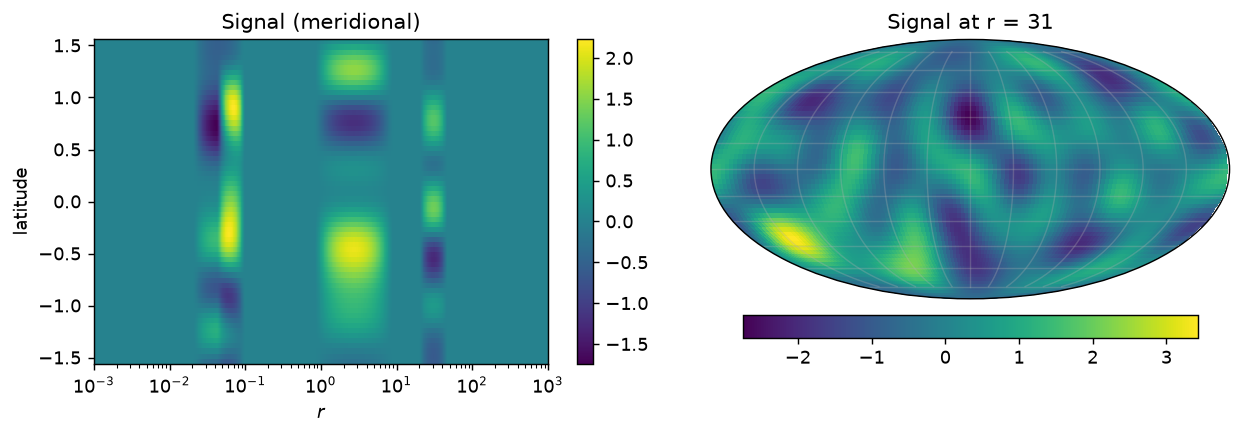

In [2]:
# radial
NR, RMIN, RMAX = 1024, 1e-3, 1e3
DOMAIN = "half-line"

#angular
NLAT, NLON = 64, 128
GRID = "legendre-gauss"

solver = RadialPoissonSolver(NLAT, NLON, NR, RMIN, RMAX, grid=GRID, domain=DOMAIN)
signal = solver.random_bump_source()

# plot signal
ir = signal.abs().amax(dim=(1, 2)).argmax().item() # interesting slice

fig = plt.figure(figsize=(10, 3.5), dpi=128)
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection="mollweide")
solver.plot_meridional(signal, ax1, title="Signal (meridional)", projection="log")
solver.plot_sphere(signal[ir], ax2, title=f"Signal at r = {solver.r[ir]:.2g}")
plt.tight_layout()
plt.show()


Above we see some sample 3D spherical data in the meridional (latitude + radial) direction on the left and an angualr slice on the right.

### 1.2 Transformations: Mellin + SHT

`torch-harmonics` provides both transformations already:

In [3]:
wmax = None
mel = MellinTransform(NR, RMIN, RMAX, wmax=wmax, domain=DOMAIN, dim=-3, c=0)
imel = InverseMellinTransform(NR, RMIN, RMAX, wmax=wmax, domain=DOMAIN, dim=-3, c=0)

# angular transformation
sht = RealSHT(NLAT, NLON, grid=GRID)
isht = InverseRealSHT(NLAT, NLON, grid=GRID)

### 1.3 Reconstruction: Roundtrip via SHT → Mellin
For the reconstruction for first move to spectral space via the SHT and Mellin and then back to the spatial space via their inverse.

In [4]:
# transformation
coeff = mel(sht(signal))
recon = isht(imel(coeff))

print(f"The spectral coefficients have shape: {tuple(coeff.shape)}")

The spectral coefficients have shape: (1024, 64, 64)


Above we see the shape of the spectral representation. This changes depending on the maxiumum modes for $\omega$, $\ell$ and m. Next we visualize the reconstructed signal:

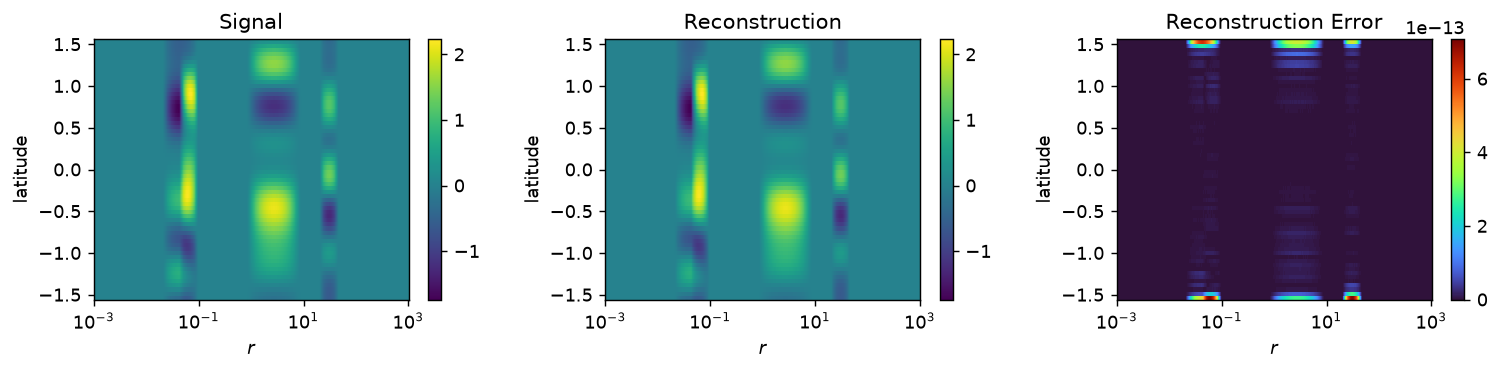

In [5]:
# plot reconstruction
fig = plt.figure(figsize=(12, 3), dpi=128)
ax1, ax2, ax3 = fig.subplots(1, 3)

solver.plot_meridional(signal, ax=ax1, title="Signal", projection="log")
solver.plot_meridional(recon, ax=ax2, title=r"Reconstruction", projection="log")
solver.plot_meridional((recon - signal).abs(), ax=ax3, title="Reconstruction Error", projection="log", cmap="turbo")
plt.tight_layout()
plt.show()

Note that the reconstruction is nearly perfect with the exception of machine precision artifacts.

To get some understanding on how the maximum mode $\omega_{max}$ affects the quality of the reconstruction we plot the roundtrip error for multiple values of $\omega_{max}$:

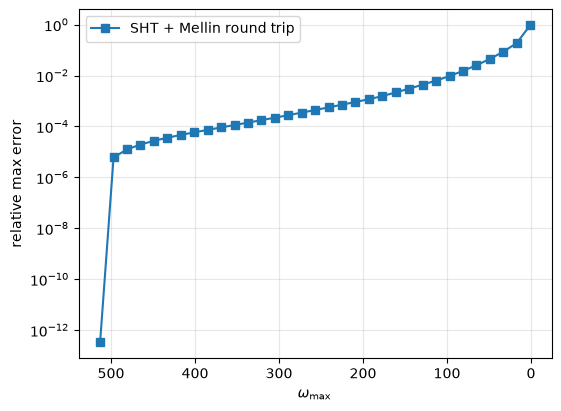

In [6]:
wmax_limit = NR //2 + 1
wmaxs = list(range(1, wmax_limit, 16)) + [wmax_limit]
err_all = []
for w in wmaxs:
    m = MellinTransform(NR, RMIN, RMAX, wmax=w, domain=DOMAIN, dim=-3)
    im = InverseMellinTransform(NR, RMIN, RMAX, wmax=w, domain=DOMAIN, dim=-3)
    recon = isht(im(m(sht(signal))))
    err_all.append((recon - signal).abs().max().item() / signal.abs().max().item())

fig, ax = plt.subplots(figsize=(5.5, 4), layout="constrained")
ax.semilogy(wmaxs, err_all, "s-", label="SHT + Mellin round trip")
ax.invert_xaxis()
ax.set_xlabel(r"$\omega_{\max}$"); ax.set_ylabel("relative max error")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

At $\omega_{max}=513$ we don't drop any frequencies and get a perfect reconstruction up to machine precision. Below, frequecies are cut out, leading to a much higher error.

## 2 Solving Spherical Poisson via Mellin

Using the Mellin transformation we can also solve the Poisson equation as an alternative to the Green's operator approach in `notebooks/poisson_equation.ipynb`. There we saw that a spherical harmonic transform reduces the Poisson equation $\Delta u = f$ to one ODE per degree $\ell$. For the log coordinate $x = \log r$ we get
$$\partial_x^2 u_\ell + \partial_x u_\ell - \ell(\ell+1)\, u_\ell = r^2 f_\ell ,$$
which can be diagonalized by the Mellin transformed of $u_\ell$. Using the derivative property $\mathcal M [ \partial_x f ] = -s \mathcal M [ f ]$ of Mellin, the solution of the ODE becomes a division by the symbol
$$\sigma_\ell(s) = s^2 - s - \ell(\ell+1),$$

and the solution of Poission per $\ell$ is given by
$$u_\ell = \mathcal M^{-1} \left [ \mathcal M [ r^2 f_{\ell} ] \sigma^{-1}_\ell(s)  \right] .$$

In [7]:
c = 0.5
padding = NR # because of fourier periodicity numerics -> our shift r^c is not enough here
mel = RealMellinTransform(NR, RMIN, RMAX, domain=DOMAIN, c=c, dim=0, npad=padding)
imel = InverseRealMellinTransform(NR, RMIN, RMAX, domain=DOMAIN, c=c, dim=0, npad=padding)
omega = mel.omega
r = solver.r.reshape(NR, 1, 1)
x = solver.x.reshape(NR, 1, 1)

def mellin_symbol(omega, l=0.0, c=0.0):
    s = c - 1j * omega
    return s**2 - s - l * (l + 1)

def solve_mellin_l(f, l):
    vhat = mel(r**2 * f)
    ms = mellin_symbol(omega, l, mel.c).reshape(-1, 1, 1)
    return imel(vhat / ms)

for $\ell=0$ and a ball source (constant in angular direction) we can solve easily via both, the solver and the Mellin derivative:

In [8]:
f = solver.ball_source()

u_solver = solver.solve(f)
u_mellin = solve_mellin_l(f, l=0)

Next we visualize the solutions via Green and Mellin

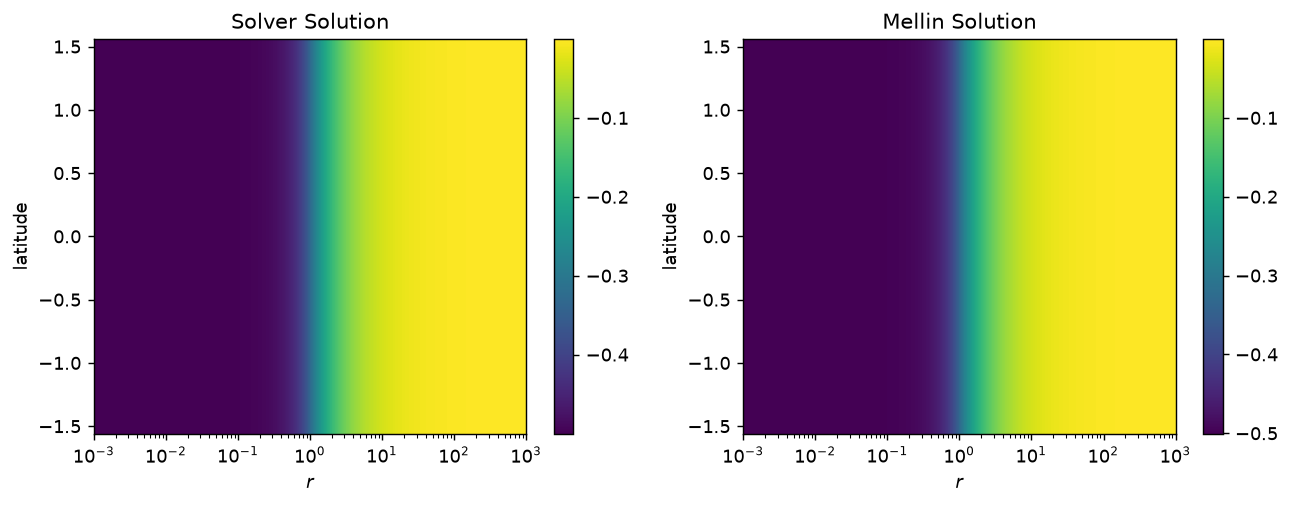

In [9]:
# plot solution
fig = plt.figure(figsize=(12, 4), dpi=128)
ax1, ax2 = fig.subplots(1, 2, width_ratios=[1, 1])

solver.plot_meridional(u_solver, ax=ax1, title=r"Solver Solution", projection="log")
solver.plot_meridional(u_mellin, ax=ax2, title=r"Mellin Solution", projection="log")

plt.show()

## 3 Learn Poisson via the Mellin+SHT Convolution

Similar to the `SpectralConvS2` based on a Driscoll-Healy Convolution utilizing the SHT, we can define a 3D spherical spectral convolution by combining the SHT and Mellin. todo further intro...

The idea is to train a `SpectralConvRadialS2` convolution via gradient descent for a known and fairly easy case. In section 2 we already explored how to solve the Poisson equation via the Mellin transform and in theory the linear convolution layer should be able to reproduce the mellin symbol $\delta_\ell(\omega)$ already. 

First we setup our Poisson data again to a smaller grid size and generate data with ball sources with $\ell=0$. 

In [10]:
from torch_harmonics import SpectralConvRadialS2

# data grid
NR, NLAT, NLON = 256, 16, 32
RMIN, RMAX = 1e-3, 1e3
DOMAIN, GRID = "half-line", "legendre-gauss"
NPAD = 3 * NR

solver = RadialPoissonSolver(NLAT, NLON, NR, RMIN, RMAX, grid=GRID, domain=DOMAIN)
r = solver.r.reshape(-1, 1, 1)
shape = (NR, NLAT, NLON)

Our input data are Ball-sources with log-uniform radii in [0.1, 10]. We set the value to 1/a², so the input g = (r/a)² peaks at 1 and u(0) = −½ for every radius.

In [11]:
def ball_data(n, amin=1e-1, amax=1e1):
    radii = amin * (amax / amin) ** torch.rand(n)
    f = torch.stack([solver.ball_source(radius=a.item(), value=1.0 / a.item() ** 2) for a in radii])
    u = solver.solve(f)
    return (r**2 * f).unsqueeze(1).float(), u.unsqueeze(1).float()


x_train, y_train = ball_data(256)
x_test, y_test = ball_data(16)
print(f"input {tuple(x_train.shape)}, target {tuple(y_train.shape)}")

input (256, 1, 256, 16, 32), target (256, 1, 256, 16, 32)


Next we initialize a `SpectralConvRadialS2` with zero weights and setup the training pipeline. We use an LBFGS optimizer with a usual MSE loss.

In [12]:
from tqdm.notebook import tqdm

# convolution
WMAX = 256
C = 0.5
conv = SpectralConvRadialS2(shape, shape, 1, 1, RMIN, RMAX, grid_in=GRID, grid_out=GRID,
                                domain=DOMAIN, lmax=1, mmax=1, wmax=WMAX, npad=NPAD, c=C)
conv.weight.data.zero_()

print(f"conv weight shape {tuple(conv.weight.shape)}")

conv weight shape (1, 1, 1, 256, 1)


Next we setup the optimizer and the training loop:

  0%|          | 0/15 [00:00<?, ?it/s]

/Users/tmarkmann/coding/radial-sfno/.venv/lib/python3.11/site-packages/torch/_inductor/lowering.py:2633: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


test rel. error 1.1e-03


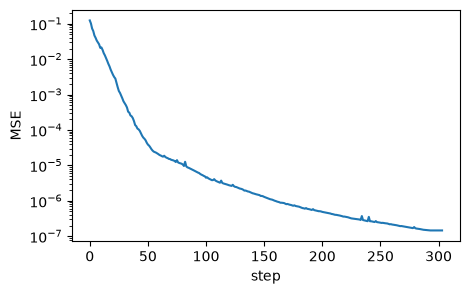

In [13]:
nsteps, batch_size = 2000, 16
loss_fn = torch.nn.MSELoss()
opt = torch.optim.LBFGS(conv.parameters(), lr=1.0, max_iter=100, history_size=50, line_search_fn="strong_wolfe")

history = []
def step_fn():
    opt.zero_grad()
    loss = loss_fn(conv(x_train), y_train)
    loss.backward()
    history.append(loss.item())
    return loss

# training loop
for _ in tqdm(range(15)):
    opt.step(step_fn)


with torch.no_grad():
    err = ((conv(x_test) - y_test).norm() / y_test.norm()).item()
    print(f"test rel. error {err:.1e}")

fig, ax = plt.subplots(figsize=(5, 3))
ax.semilogy(history)
ax.set_xlabel("step"); ax.set_ylabel("MSE")
plt.show()

Finally, we test the linear model on the test set:

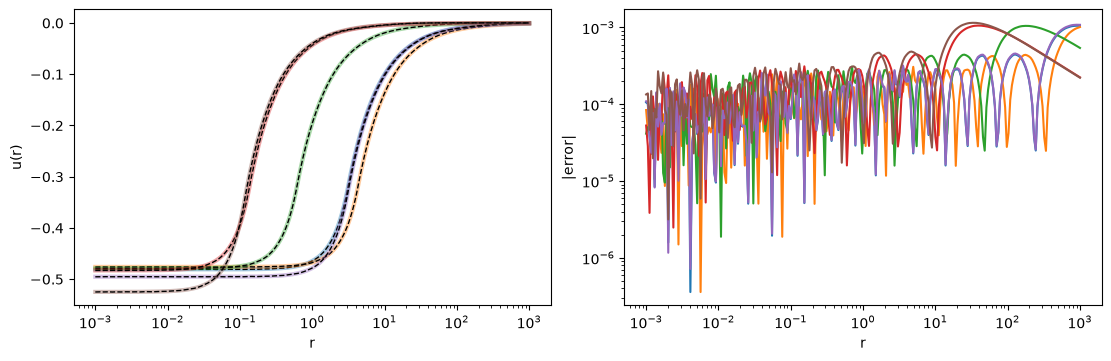

In [14]:
with torch.no_grad():
    pred = conv(x_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")
for i in range(6):
    ax1.semilogx(solver.r, y_test[i, 0, :, 0, 0], lw=3, alpha=0.4)
    ax1.semilogx(solver.r, pred[i, 0, :, 0, 0], "k--", lw=1)
    ax2.loglog(solver.r, (pred[i, 0, :, 0, 0] - y_test[i, 0, :, 0, 0]).abs())
ax1.set_xlabel("r"); ax1.set_ylabel("u(r)")
ax2.set_xlabel("r"); ax2.set_ylabel("|error|")
plt.show()


We see that the convolution did a good job here and we can learn the ball case with only a linear convolution layer already!

Since the layer is linear, its weights can be read directly and they should match 1/σ₀.

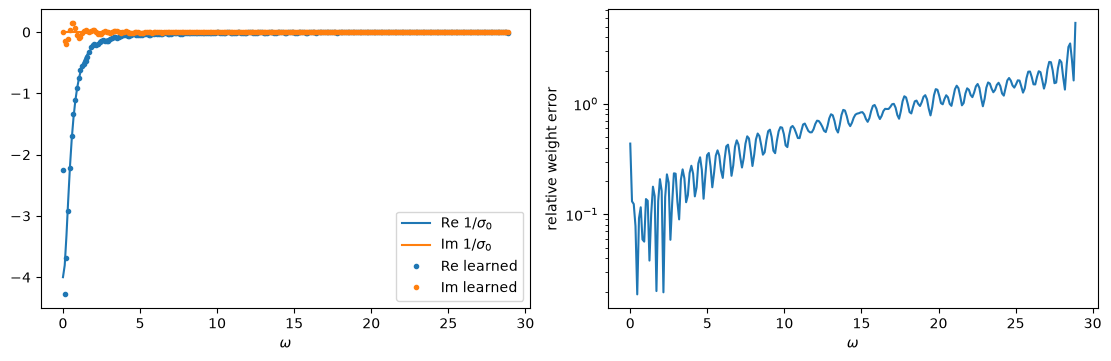

In [15]:
learned = conv.weight.detach()[0, 0, 0, :, 0] # TODO is this correct and what about the other ones?
omega = conv.mellin.omega
exact = 1 / mellin_symbol(omega, c=C)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")
ax1.plot(omega, exact.real, label=r"Re $1/\sigma_0$", color="C0")
ax1.plot(omega, exact.imag, label=r"Im $1/\sigma_0$", color="C1")
ax1.plot(omega, learned.real, ".", label="Re learned", color="C0")
ax1.plot(omega, learned.imag, ".", label="Im learned", color="C1")
ax1.set_xlabel(r"$\omega$")
ax1.legend()

ax2.semilogy(omega, (learned - exact).abs() / exact.abs())
ax2.set_xlabel(r"$\omega$"); ax2.set_ylabel("relative weight error")
plt.show()